In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Statsmodels for time-series tests
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, coint_johansen
from statsmodels.tools.sm_exceptions import InfeasibleTestError

# ML imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import shap

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


/Users/rr/Documents/Diajeng/citi/timexer/TimeXer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('.././dataset/forPaper/Kaohsiung_DCS002_All_10_Minutely.csv')


In [3]:
df.head()

,Date Time,DCS002 Real Output Power,DCS002 Real Irradiance,Simulated Output Power from DCS002 Real Irradiance,Simulated Power Generated,Simulated DC Inverter Input,Plane Of Array Irradiance,Transmitted Plane Of Array Irradiance,Module Temperature,DHI,...,Elevation Radiant,Azimuth Radiant,Angle Of Incidence Radiant,Hour Angle Radiant,Airmass Relative,Airmass Absolute,Latitude,Longitude,Time Zone,Altitude
0,2019-12-01 00:00:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,...,-1.515869,1.238594,0.0,-3.085705,0.0,0.0,22.72,120.35,Asia/Taipei,22
1,2019-12-01 00:10:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,...,-1.476853,1.392141,0.0,-3.042082,0.0,0.0,22.72,120.35,Asia/Taipei,22
2,2019-12-01 00:20:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,...,-1.437030,1.459931,0.0,-2.998460,0.0,0.0,22.72,120.35,Asia/Taipei,22
3,2019-12-01 00:30:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,...,-1.396960,1.500401,0.0,-2.954838,0.0,0.0,22.72,120.35,Asia/Taipei,22
4,2019-12-01 00:40:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,0,...,-1.356790,1.528855,0.0,-2.911216,0.0,0.0,22.72,120.35,Asia/Taipei,22


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57168 entries, 0 to 57167
Data columns (total 62 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Date Time                                           57168 non-null  object 
 1   DCS002 Real Output Power                            57168 non-null  float64
 2   DCS002 Real Irradiance                              57168 non-null  float64
 3   Simulated Output Power from DCS002 Real Irradiance  57168 non-null  float64
 4   Simulated Power Generated                           57168 non-null  float64
 5   Simulated DC Inverter Input                         57168 non-null  float64
 6   Plane Of Array Irradiance                           57168 non-null  float64
 7   Transmitted Plane Of Array Irradiance               57168 non-null  float64
 8   Module Temperature                                  57168 non-null  float64


In [5]:
df.shape[0], df.shape[1]

(57168, 62)

In [6]:
df.index = pd.to_datetime(df['Date Time'], format='ISO8601')
df.drop(columns=['Date Time'], inplace=True)


In [7]:
df.head()

,DCS002 Real Output Power,DCS002 Real Irradiance,Simulated Output Power from DCS002 Real Irradiance,Simulated Power Generated,Simulated DC Inverter Input,Plane Of Array Irradiance,Transmitted Plane Of Array Irradiance,Module Temperature,DHI,DNI,...,Elevation Radiant,Azimuth Radiant,Angle Of Incidence Radiant,Hour Angle Radiant,Airmass Relative,Airmass Absolute,Latitude,Longitude,Time Zone,Altitude
Date Time,,,,,,,,,,,,,,,,,,,,,
2019-12-01 00:00:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,0,...,-1.515869,1.238594,0.0,-3.085705,0.0,0.0,22.72,120.35,Asia/Taipei,22
2019-12-01 00:10:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,0,...,-1.476853,1.392141,0.0,-3.042082,0.0,0.0,22.72,120.35,Asia/Taipei,22
2019-12-01 00:20:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,0,...,-1.437030,1.459931,0.0,-2.998460,0.0,0.0,22.72,120.35,Asia/Taipei,22
2019-12-01 00:30:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.1,0,0,...,-1.396960,1.500401,0.0,-2.954838,0.0,0.0,22.72,120.35,Asia/Taipei,22
2019-12-01 00:40:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,0,0,...,-1.356790,1.528855,0.0,-2.911216,0.0,0.0,22.72,120.35,Asia/Taipei,22


In [8]:
df.tail()

,DCS002 Real Output Power,DCS002 Real Irradiance,Simulated Output Power from DCS002 Real Irradiance,Simulated Power Generated,Simulated DC Inverter Input,Plane Of Array Irradiance,Transmitted Plane Of Array Irradiance,Module Temperature,DHI,DNI,...,Elevation Radiant,Azimuth Radiant,Angle Of Incidence Radiant,Hour Angle Radiant,Airmass Relative,Airmass Absolute,Latitude,Longitude,Time Zone,Altitude
Date Time,,,,,,,,,,,,,,,,,,,,,
2020-12-31 23:10:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.362312,4.642496,0.0,2.915321,0.0,0.0,22.72,120.35,Asia/Taipei,22
2020-12-31 23:20:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.402450,4.644914,0.0,2.958939,0.0,0.0,22.72,120.35,Asia/Taipei,22
2020-12-31 23:30:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.442591,4.643472,0.0,3.002558,0.0,0.0,22.72,120.35,Asia/Taipei,22
2020-12-31 23:40:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.482716,4.632941,0.0,3.046177,0.0,0.0,22.72,120.35,Asia/Taipei,22
2020-12-31 23:50:00+08:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.7,0,0,...,-1.522763,4.590637,0.0,3.089796,0.0,0.0,22.72,120.35,Asia/Taipei,22


In [9]:
print(df.index.freq)
print(df.index[:5])


None
DatetimeIndex(['2019-12-01 00:00:00+08:00', '2019-12-01 00:10:00+08:00',
               '2019-12-01 00:20:00+08:00', '2019-12-01 00:30:00+08:00',
               '2019-12-01 00:40:00+08:00'],
              dtype='datetime64[ns, UTC+08:00]', name='Date Time', freq=None)


In [10]:
df = df.sort_index()
df = df.select_dtypes(include='number').resample('10min').mean()
print(df.index.freq)


<10 * Minutes>


In [11]:
df_2019 = df.loc['2019-12-01 00:00:00+08:00':'2019-12-31 23:50:00+08:00'].copy()
df_2020 = df.loc['2020-01-01 00:00:00+08:00':'2020-12-31 23:50:00+08:00'].copy()

df_2019.head(), df_2020.head()


(                           DCS002 Real Output Power  DCS002 Real Irradiance  \
 Date Time                                                                     
 2019-12-01 00:00:00+08:00                       0.0                     0.0   
 2019-12-01 00:10:00+08:00                       0.0                     0.0   
 2019-12-01 00:20:00+08:00                       0.0                     0.0   
 2019-12-01 00:30:00+08:00                       0.0                     0.0   
 2019-12-01 00:40:00+08:00                       0.0                     0.0   
 
                            Simulated Output Power from DCS002 Real Irradiance  \
 Date Time                                                                       
 2019-12-01 00:00:00+08:00                                                0.0    
 2019-12-01 00:10:00+08:00                                                0.0    
 2019-12-01 00:20:00+08:00                                                0.0    
 2019-12-01 00:30:00+08:00  

# Focus: 2020

Goal: identify the best predictor variables for GHI time-series forecasting,
based on professor's recommendations. We drop all **Simulated** columns and
use physics-based + meteorological + temporal features only.


In [12]:
# ── Curated feature set (professor recommendation) ───────────────────────────
# DROPPED:  all Simulated*, Day Length, Equation of Time, Azimuth,
#           redundant Radiant columns (deg→rad duplicates)
# KEPT:     physics-based, meteorological, cyclic-temporal

TARGET = 'GHI'

FEATURES = [
    # ── Atmospheric / meteorological ──────────────────────────────────────
    'Cloud Type',
    'Temperature',
    'Dew Point',
    'Ozone',
    'Relative Humidity',
    'Solar Zenith Angle',
    'Surface Albedo',
    'Pressure',
    'Precipitable Water',           # ⭐ most important (water vapour ↔ attenuation)
    'Wind Direction',
    'Wind Speed',
    'Airmass Relative',             # radiation path length through atmosphere

    # ── Irradiance components (non-simulated) ─────────────────────────────
    'Transmitted Plane Of Array Irradiance',
    'Clearsky GHI',
    'DHI',

    # ── Sun geometry ──────────────────────────────────────────────────────
    'Angle of Incidence',
    'Hour Angle',
    'Sun Up Over Horizon',          # binary flag — night / day

    # ── Cyclic temporal encoding ──────────────────────────────────────────
    'Day sin',
    'Day cos',
    'Year sin',
    'Year cos',
]

available = [c for c in FEATURES if c in df_2020.columns]
missing   = [c for c in FEATURES if c not in df_2020.columns]

if missing:
    print(f"⚠️  Columns not found in df_2020 (check exact names):\n  {missing}")
print(f"\n✅ Using {len(available)} features:")
for f in available:
    print(f"   {f}")

# Working dataframe: curated features + target
analysis_df = df_2020[available + [TARGET]].copy()



✅ Using 22 features:
   Cloud Type
   Temperature
   Dew Point
   Ozone
   Relative Humidity
   Solar Zenith Angle
   Surface Albedo
   Pressure
   Precipitable Water
   Wind Direction
   Wind Speed
   Airmass Relative
   Transmitted Plane Of Array Irradiance
   Clearsky GHI
   DHI
   Angle of Incidence
   Hour Angle
   Sun Up Over Horizon
   Day sin
   Day cos
   Year sin
   Year cos


In [13]:
df_2020.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52704 entries, 2020-01-01 00:00:00+08:00 to 2020-12-31 23:50:00+08:00
Freq: 10min
Data columns (total 57 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   DCS002 Real Output Power                            52704 non-null  float64
 1   DCS002 Real Irradiance                              52704 non-null  float64
 2   Simulated Output Power from DCS002 Real Irradiance  52704 non-null  float64
 3   Simulated Power Generated                           52704 non-null  float64
 4   Simulated DC Inverter Input                         52704 non-null  float64
 5   Plane Of Array Irradiance                           52704 non-null  float64
 6   Transmitted Plane Of Array Irradiance               52704 non-null  float64
 7   Module Temperature                                  52704 non-null  float64
 8   DHI              

## 1. Correlation Analysis

### 1a. Each feature vs GHI (Pearson r)


                                       Pearson r       |r|
Transmitted Plane Of Array Irradiance   0.987564  0.987564
Clearsky GHI                            0.924866  0.924866
Solar Zenith Angle                     -0.820173  0.820173
DHI                                     0.785864  0.785864
Sun Up Over Horizon                     0.707433  0.707433
Day sin                                 0.691931  0.691931
Relative Humidity                      -0.653193  0.653193
Temperature                             0.472167  0.472167
Day cos                                 0.427292  0.427292
Angle of Incidence                      0.264286  0.264286
Wind Speed                              0.212921  0.212921
Wind Direction                          0.147877  0.147877
Cloud Type                             -0.131761  0.131761
Ozone                                   0.115347  0.115347
Year cos                               -0.110636  0.110636
Pressure                               -0.067842  0.0678

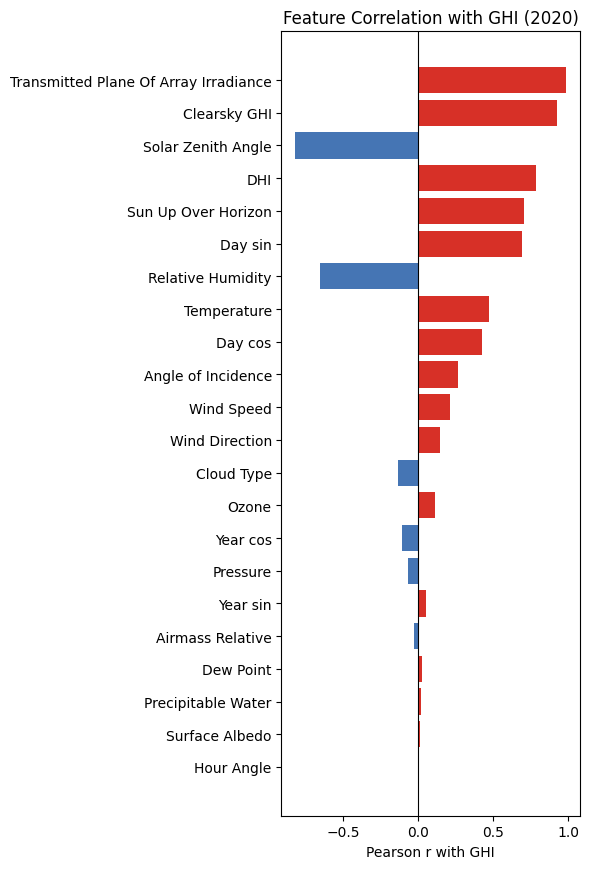

In [14]:
corr_with_ghi = (
    analysis_df.corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
    .to_frame(name='Pearson r')
)
corr_with_ghi['|r|'] = corr_with_ghi['Pearson r'].abs()

print(corr_with_ghi.to_string())

plt.figure(figsize=(6, max(5, 0.4 * len(corr_with_ghi))))
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_with_ghi['Pearson r']]
plt.barh(corr_with_ghi.index, corr_with_ghi['Pearson r'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson r with GHI')
plt.title('Feature Correlation with GHI (2020)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 1b. Feature × Feature heatmap (multicollinearity check)


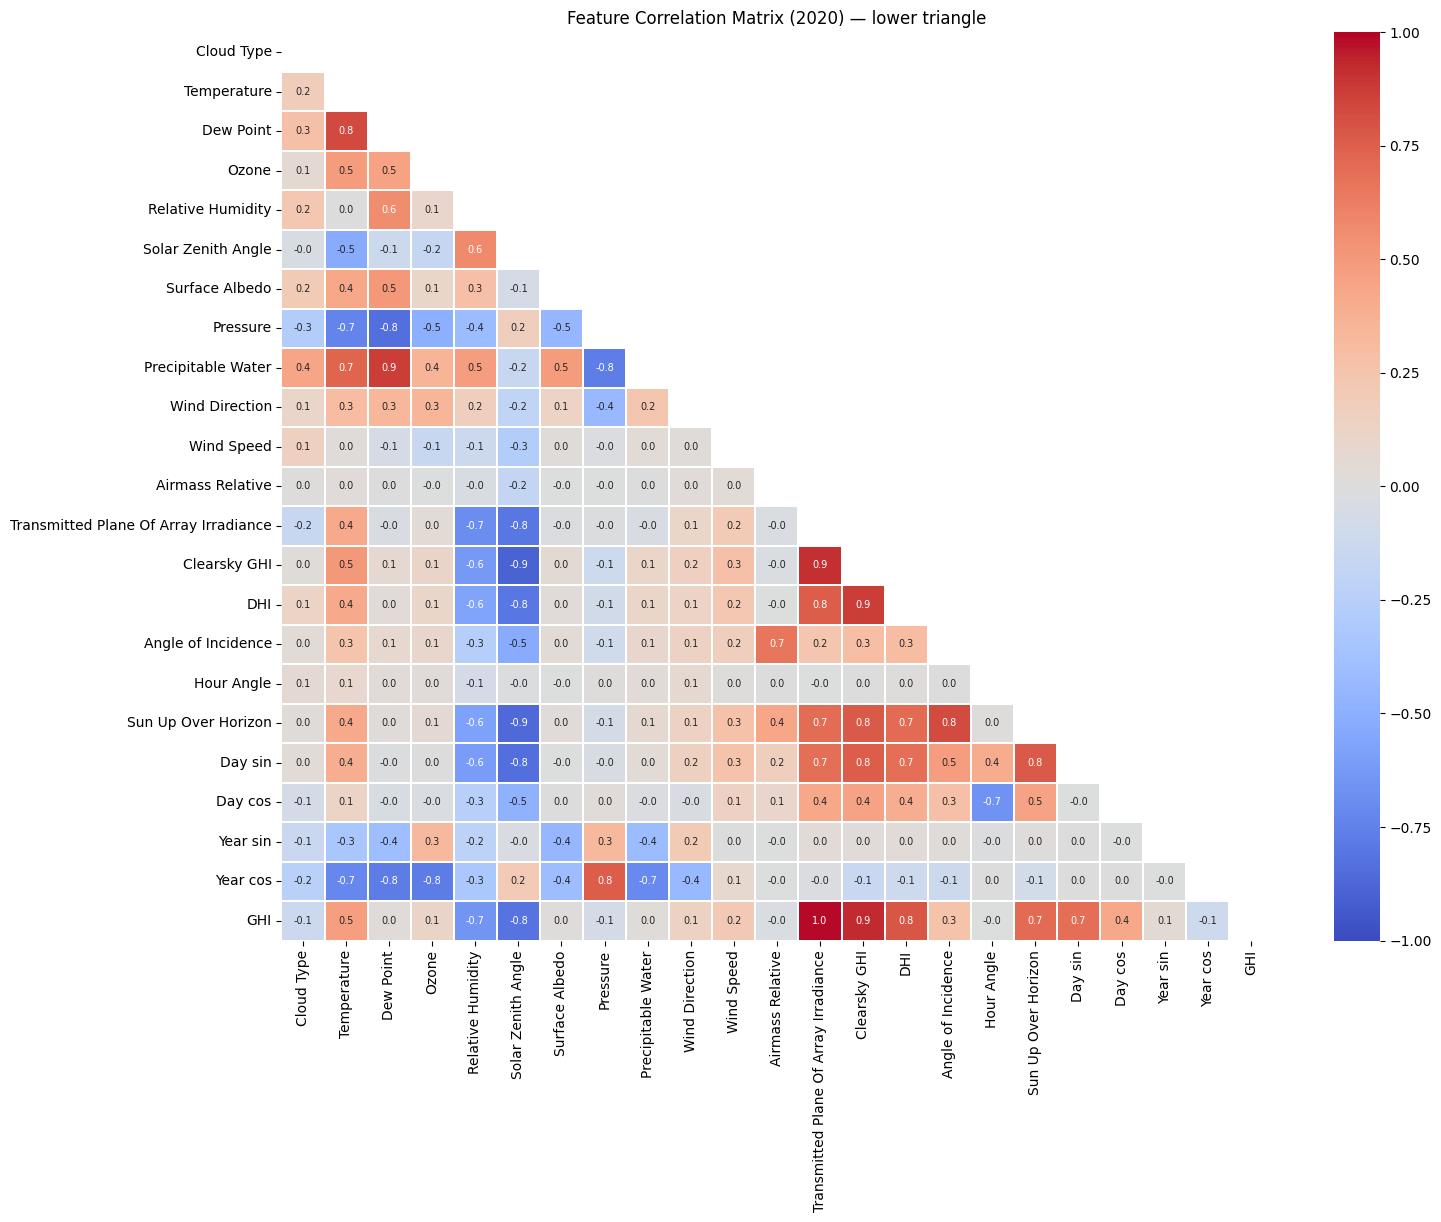

In [15]:
corr_full = analysis_df.corr()

fig_size = max(14, len(available) * 0.7)
plt.figure(figsize=(fig_size, fig_size * 0.8))
mask = np.triu(np.ones_like(corr_full, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_full, mask=mask,
    annot=True, fmt='.1f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.3, annot_kws={'size': 7}
)
plt.title('Feature Correlation Matrix (2020) — lower triangle')
plt.tight_layout()
plt.show()


## 2. Stationarity — ADF Test

A series must be integrated of the same order for VECM. We check each feature.


In [16]:
print("=== ADF Stationarity Test (2020 curated features) ===\n")

for col in available + [TARGET]:
    series = analysis_df[col].dropna()
    print(f"Column: {col}")

    if series.nunique() < 2:
        print("  => Skipped: constant series\n")
        continue

    try:
        adf_stat, p_value, _, _, crit_values, _ = adfuller(series)
    except Exception as e:
        print(f"  => Skipped: {e}\n")
        continue

    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    for k, v in crit_values.items():
        print(f"  Critical {k}  : {v:.4f}")
    status = "✅ Stationary (reject H0)" if p_value < 0.05 else "⚠️  Non-stationary"
    print(f"  => {status}\n")


=== ADF Stationarity Test (2020 curated features) ===

Column: Cloud Type
  ADF Statistic : -13.7586
  p-value       : 0.0000
  Critical 1%  : -3.4305
  Critical 5%  : -2.8616
  Critical 10%  : -2.5668
  => ✅ Stationary (reject H0)

Column: Temperature
  ADF Statistic : -9.8313
  p-value       : 0.0000
  Critical 1%  : -3.4305
  Critical 5%  : -2.8616
  Critical 10%  : -2.5668
  => ✅ Stationary (reject H0)

Column: Dew Point
  ADF Statistic : -3.2679
  p-value       : 0.0164
  Critical 1%  : -3.4305
  Critical 5%  : -2.8616
  Critical 10%  : -2.5668
  => ✅ Stationary (reject H0)

Column: Ozone
  ADF Statistic : -3.9257
  p-value       : 0.0019
  Critical 1%  : -3.4305
  Critical 5%  : -2.8616
  Critical 10%  : -2.5668
  => ✅ Stationary (reject H0)

Column: Relative Humidity
  ADF Statistic : -20.6521
  p-value       : 0.0000
  Critical 1%  : -3.4305
  Critical 5%  : -2.8616
  Critical 10%  : -2.5668
  => ✅ Stationary (reject H0)

Column: Solar Zenith Angle
  ADF Statistic : -25.5684
  

## 3. Granger Causality

Does each feature Granger-cause GHI? Using 24 lags (= 4 hours at 10-min freq).


In [17]:
daily_data = df_2020.select_dtypes(include='number').resample('10min').mean()

MAXLAG      = 24   # 4 hours at 10-min resolution
output_file = "./granger_causality_results2.txt"

granger_summary = {}   # col → list of significant lags

with open(output_file, "w") as file:
    for col in available:
        if col == TARGET:
            continue

        file.write(f'Granger Causality: does "{col}" cause "{TARGET}"?\n')
        data_for_test = daily_data[[TARGET, col]].dropna()

        if len(data_for_test) < MAXLAG * 3:
            file.write("  Skipped: insufficient observations.\n\n")
            continue
        if data_for_test[col].nunique() < 2:
            file.write("  Skipped: constant series.\n\n")
            continue

        try:
            result = grangercausalitytests(data_for_test, maxlag=MAXLAG, verbose=False)
            sig_lags = []
            for lag in range(1, MAXLAG + 1):
                p = result[lag][0]['ssr_chi2test'][1]
                file.write(f"  Lag {lag:2d}: p = {p:.4f}\n")
                if p < 0.05:
                    sig_lags.append(lag)

            granger_summary[col] = sig_lags
            if sig_lags:
                file.write(f"  => SIGNIFICANT at lags {sig_lags}\n\n")
            else:
                file.write(f"  => Not significant\n\n")

        except InfeasibleTestError:
            file.write("  => Infeasible (perfect collinearity)\n\n")
        except Exception as e:
            file.write(f"  => Error: {e}\n\n")

print(f"Results saved to {output_file}\n")
print("=== Granger Causality Summary ===")
for col, lags in granger_summary.items():
    status = f"✅ significant ({len(lags)} lags)" if lags else "✗ not significant"
    print(f"  {col:<45} {status}")

granger_features = [c for c, lags in granger_summary.items() if lags]
print(f"\nFeatures with Granger causality on GHI: {granger_features}")


Results saved to ./granger_causality_results2.txt

=== Granger Causality Summary ===
  Cloud Type                                    ✅ significant (20 lags)
  Temperature                                   ✅ significant (24 lags)
  Dew Point                                     ✅ significant (23 lags)
  Ozone                                         ✅ significant (14 lags)
  Relative Humidity                             ✅ significant (24 lags)
  Solar Zenith Angle                            ✅ significant (24 lags)
  Surface Albedo                                ✅ significant (4 lags)
  Pressure                                      ✅ significant (24 lags)
  Precipitable Water                            ✅ significant (23 lags)
  Wind Direction                                ✅ significant (17 lags)
  Wind Speed                                    ✅ significant (24 lags)
  Airmass Relative                              ✅ significant (24 lags)
  Transmitted Plane Of Array Irradiance         ✅ si

## 4. VECM — Vector Error Correction Model

VIF pruning is applied first to remove near-collinear columns and prevent the
`LinAlgError: Matrix is not positive definite` failure.


In [18]:
# ── Step 0: Start from curated set on daily_data ─────────────────────────────
data_vecm = daily_data[available].dropna().copy()
print(f"Starting columns ({data_vecm.shape[1]}): {list(data_vecm.columns)}")

# ── Step 1: VIF pruning ───────────────────────────────────────────────────────
def prune_by_vif(df, threshold=10.0):
    """Iteratively drop the highest-VIF column until all VIFs are below threshold."""
    cols = list(df.columns)
    iteration = 0
    while True:
        iteration += 1
        vifs = pd.Series(
            [variance_inflation_factor(df[cols].values, i) for i in range(len(cols))],
            index=cols
        )
        worst = vifs.idxmax()
        if vifs[worst] > threshold:
            print(f"  [{iteration}] Drop '{worst}' (VIF={vifs[worst]:.1f})")
            cols.remove(worst)
        else:
            print(f"  ✅ Converged after {iteration} iterations — {len(cols)} columns remain")
            break
    return df[cols], vifs[cols]

print("\nVIF pruning (threshold=10):")
data_vecm, final_vifs = prune_by_vif(data_vecm, threshold=10.0)

# ── Step 2: Drop zero-variance columns ───────────────────────────────────────
zero_var = [c for c in data_vecm.columns if data_vecm[c].nunique() < 2]
if zero_var:
    print(f"Dropping zero-variance: {zero_var}")
    data_vecm = data_vecm.drop(columns=zero_var)

vecm_features = list(data_vecm.columns)
print(f"\nFinal VECM columns ({len(vecm_features)}): {vecm_features}")
print("\nFinal VIFs:")
print(final_vifs.sort_values(ascending=False).to_string())

# ── Step 3: Safe maxlags ──────────────────────────────────────────────────────
n_obs, n_vars = data_vecm.shape
safe_maxlags = max(1, min(8, n_obs // (10 * max(n_vars, 1))))
print(f"\nn_obs={n_obs}, n_vars={n_vars}, safe_maxlags={safe_maxlags}")

# ── Step 4: Select optimal lag (AIC) ─────────────────────────────────────────
order_results = select_order(data_vecm, maxlags=safe_maxlags, deterministic="co")
optimal_lag   = max(1, int(order_results.aic or 1))
print("Optimal lag (AIC):", optimal_lag)

# ── Step 5: Johansen cointegration test ──────────────────────────────────────
johansen_test = coint_johansen(data_vecm, det_order=0, k_ar_diff=optimal_lag)
print("\nJohansen Eigenvalues:", johansen_test.eig)
print("Trace Statistics:   ", johansen_test.lr1)
print("Critical Values (90%, 95%, 99%):\n", johansen_test.cvt)

# ── Step 6: Fit VECM ─────────────────────────────────────────────────────────
coint_rank  = int(np.sum(johansen_test.lr1 > johansen_test.cvt[:, 1]))  # 95%
coint_rank  = max(1, coint_rank)
print(f"\nCointegration rank used: {coint_rank}")

vecm_model = VECM(data_vecm, k_ar_diff=optimal_lag,
                  coint_rank=coint_rank, deterministic="co")
vecm_res = vecm_model.fit()
print(vecm_res.summary())


Starting columns (22): ['Cloud Type', 'Temperature', 'Dew Point', 'Ozone', 'Relative Humidity', 'Solar Zenith Angle', 'Surface Albedo', 'Pressure', 'Precipitable Water', 'Wind Direction', 'Wind Speed', 'Airmass Relative', 'Transmitted Plane Of Array Irradiance', 'Clearsky GHI', 'DHI', 'Angle of Incidence', 'Hour Angle', 'Sun Up Over Horizon', 'Day sin', 'Day cos', 'Year sin', 'Year cos']

VIF pruning (threshold=10):
  [1] Drop 'Temperature' (VIF=26813.0)
  [2] Drop 'Pressure' (VIF=2853.6)
  [3] Drop 'Surface Albedo' (VIF=547.6)
  [4] Drop 'Solar Zenith Angle' (VIF=442.3)
  [5] Drop 'Relative Humidity' (VIF=390.6)
  [6] Drop 'Sun Up Over Horizon' (VIF=227.5)
  [7] Drop 'Dew Point' (VIF=200.5)
  [8] Drop 'Ozone' (VIF=47.9)
  [9] Drop 'Clearsky GHI' (VIF=26.1)
  [10] Drop 'Precipitable Water' (VIF=15.5)
  ✅ Converged after 11 iterations — 12 columns remain

Final VECM columns (12): ['Cloud Type', 'Wind Direction', 'Wind Speed', 'Airmass Relative', 'Transmitted Plane Of Array Irradiance', 

## 5. Engle–Granger Pairwise Cointegration

Checks which feature pairs share a long-run equilibrium with GHI.


In [19]:
print("=== Engle-Granger Cointegration vs GHI ===\n")

coint_results = {}

ghi_series = daily_data[TARGET].dropna()

for col in vecm_features:
    if col == TARGET:
        continue

    series = daily_data[col].dropna()
    common  = ghi_series.index.intersection(series.index)
    s_ghi   = ghi_series.loc[common]
    s_col   = series.loc[common]

    if len(s_ghi) < 20 or s_col.nunique() < 2:
        print(f"  '{col}': skipped")
        continue

    try:
        score, p_value, _ = coint(s_ghi, s_col)
        coint_results[col] = p_value
        flag = "✅ cointegrated" if p_value < 0.05 else "✗"
        print(f"  GHI × {col:<45} p={p_value:.4f}  {flag}")
    except Exception as e:
        print(f"  GHI × {col}: error — {e}")

cointegrated_features = [c for c, p in coint_results.items() if p < 0.05]
print(f"\nCointegrated with GHI (p<0.05): {cointegrated_features}")


=== Engle-Granger Cointegration vs GHI ===

  GHI × Cloud Type                                    p=0.0000  ✅ cointegrated
  GHI × Wind Direction                                p=0.0000  ✅ cointegrated
  GHI × Wind Speed                                    p=0.0000  ✅ cointegrated
  GHI × Airmass Relative                              p=0.0000  ✅ cointegrated
  GHI × Transmitted Plane Of Array Irradiance         p=0.0000  ✅ cointegrated
  GHI × DHI                                           p=0.0000  ✅ cointegrated
  GHI × Angle of Incidence                            p=0.0000  ✅ cointegrated
  GHI × Hour Angle                                    p=0.0000  ✅ cointegrated
  GHI × Day sin                                       p=0.0000  ✅ cointegrated
  GHI × Day cos                                       p=0.0000  ✅ cointegrated
  GHI × Year sin                                      p=0.0000  ✅ cointegrated
  GHI × Year cos                                      p=0.0000  ✅ cointegrated

Cointeg

# Machine Learning: Feature Importance & SHAP

Goal: predict **GHI** from the curated feature set, then rank features using
Random Forest MDI, XGBoost gain, and SHAP — to identify the optimal predictor
set for time-series forecasting.


In [20]:
# ── Use only the curated, professor-approved feature set ─────────────────────
model_df = df_2020[available + [TARGET]].dropna().copy()

# Drop zero-variance columns
const_cols = [c for c in model_df.columns if model_df[c].nunique() < 2]
if const_cols:
    print(f"Dropping zero-variance: {const_cols}")
    model_df = model_df.drop(columns=const_cols)

y = model_df[TARGET]
X = model_df.drop(columns=[TARGET])

print(f"X shape : {X.shape}")
print(f"Features: {list(X.columns)}")


X shape : (52704, 22)
Features: ['Cloud Type', 'Temperature', 'Dew Point', 'Ozone', 'Relative Humidity', 'Solar Zenith Angle', 'Surface Albedo', 'Pressure', 'Precipitable Water', 'Wind Direction', 'Wind Speed', 'Airmass Relative', 'Transmitted Plane Of Array Irradiance', 'Clearsky GHI', 'DHI', 'Angle of Incidence', 'Hour Angle', 'Sun Up Over Horizon', 'Day sin', 'Day cos', 'Year sin', 'Year cos']


In [21]:
# Time-aware split — last 20% as test (no leakage)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train : {X_train.shape} | {X_train.index.min().date()} → {X_train.index.max().date()}")
print(f"Test  : {X_test.shape}  | {X_test.index.min().date()} → {X_test.index.max().date()}")


Train : (42163, 22) | 2020-01-01 → 2020-10-19
Test  : (10541, 22)  | 2020-10-19 → 2020-12-31


## Random Forest


In [22]:
rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=None,
    min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_metrics = {
    'RMSE': float(np.sqrt(mean_squared_error(y_test, rf_pred))),
    'MAE' : float(mean_absolute_error(y_test, rf_pred)),
    'R2'  : float(r2_score(y_test, rf_pred)),
}
print("Random Forest — test metrics:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v:.4f}")


Random Forest — test metrics:
  RMSE: 6.5945
  MAE: 1.7858
  R2: 0.9992


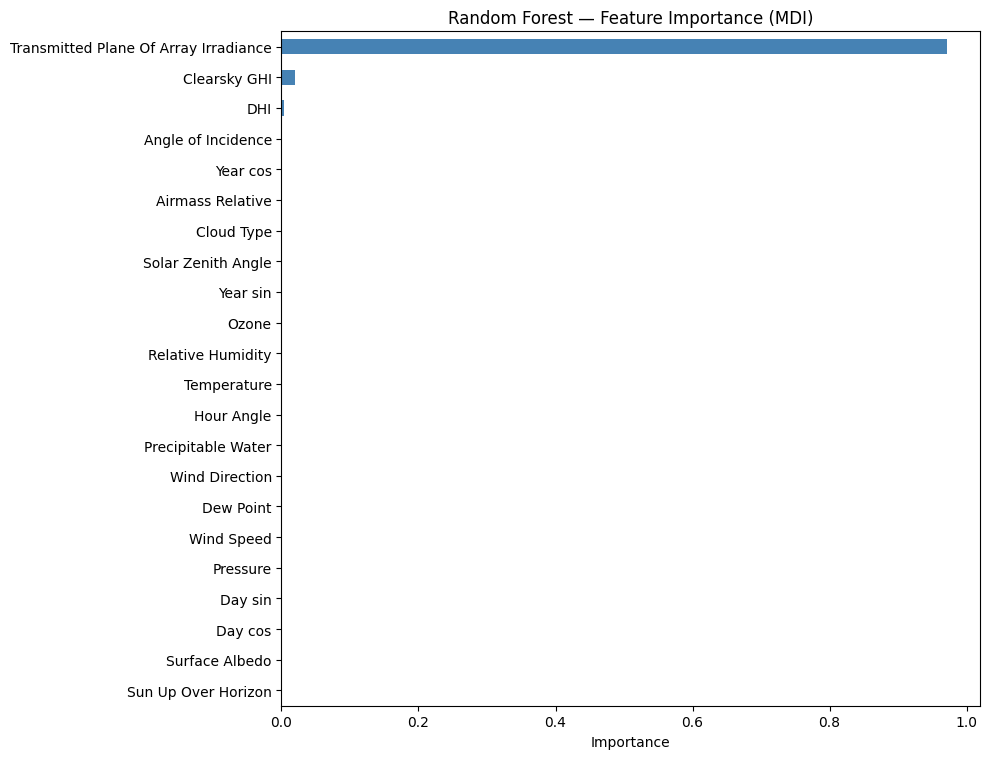

Transmitted Plane Of Array Irradiance    0.971006
Clearsky GHI                             0.019999
DHI                                      0.004327
Angle of Incidence                       0.001340
Year cos                                 0.001050
Airmass Relative                         0.000918
Cloud Type                               0.000663
Solar Zenith Angle                       0.000514
Year sin                                 0.000077
Ozone                                    0.000036
Relative Humidity                        0.000010
Temperature                              0.000009
Hour Angle                               0.000009
Precipitable Water                       0.000008
Wind Direction                           0.000008
dtype: float64

In [23]:
rf_importance = (
    pd.Series(rf_model.feature_importances_, index=X.columns)
      .sort_values(ascending=True)
)
plt.figure(figsize=(10, max(4, 0.35 * len(rf_importance))))
rf_importance.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance (MDI)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

rf_importance.sort_values(ascending=False).head(15)


## XGBoost


In [24]:
xgb_model = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist',
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_metrics = {
    'RMSE': float(np.sqrt(mean_squared_error(y_test, xgb_pred))),
    'MAE' : float(mean_absolute_error(y_test, xgb_pred)),
    'R2'  : float(r2_score(y_test, xgb_pred)),
}
print("XGBoost — test metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v:.4f}")


XGBoost — test metrics:
  RMSE: 3.9056
  MAE: 1.7437
  R2: 0.9997


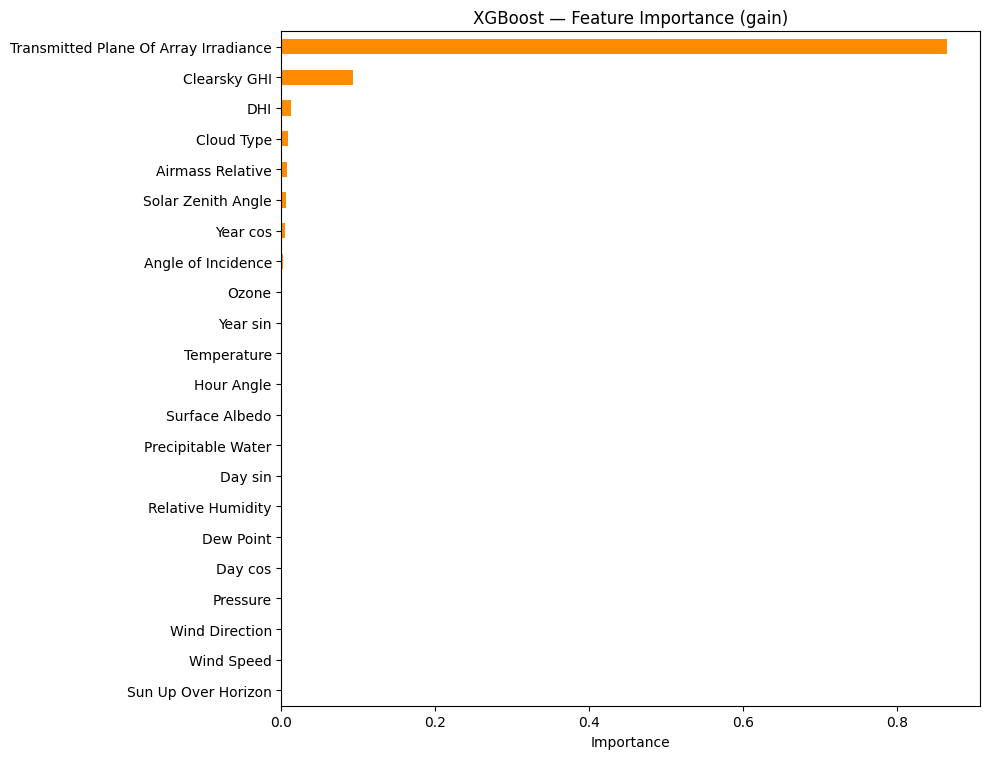

Transmitted Plane Of Array Irradiance    0.864856
Clearsky GHI                             0.093148
DHI                                      0.011918
Cloud Type                               0.009069
Airmass Relative                         0.007571
Solar Zenith Angle                       0.005754
Year cos                                 0.004086
Angle of Incidence                       0.002221
Ozone                                    0.000710
Year sin                                 0.000273
Temperature                              0.000087
Hour Angle                               0.000087
Surface Albedo                           0.000060
Precipitable Water                       0.000037
Day sin                                  0.000025
dtype: float32

In [25]:
xgb_importance = (
    pd.Series(xgb_model.feature_importances_, index=X.columns)
      .sort_values(ascending=True)
)
plt.figure(figsize=(10, max(4, 0.35 * len(xgb_importance))))
xgb_importance.plot(kind='barh', color='darkorange')
plt.title('XGBoost — Feature Importance (gain)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

xgb_importance.sort_values(ascending=False).head(15)


In [26]:
metrics_df = pd.DataFrame({'RandomForest': rf_metrics, 'XGBoost': xgb_metrics}).T
metrics_df


,RMSE,MAE,R2
RandomForest,6.594550,1.785766,0.999178
XGBoost,3.905587,1.743749,0.999712


## SHAP Explanations

SHAP decomposes each prediction into additive feature contributions — showing
not just *which* features matter but *how* and *how much*.


In [27]:
SHAP_SAMPLE = min(1000, len(X_test))
X_shap = X_test.sample(SHAP_SAMPLE, random_state=RANDOM_STATE).sort_index()
print(f"SHAP sample size: {len(X_shap)}")


SHAP sample size: 1000


### SHAP — Random Forest


In [28]:
rf_explainer   = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_shap)
print("SHAP values shape:", np.shape(rf_shap_values))


SHAP values shape: (1000, 22)


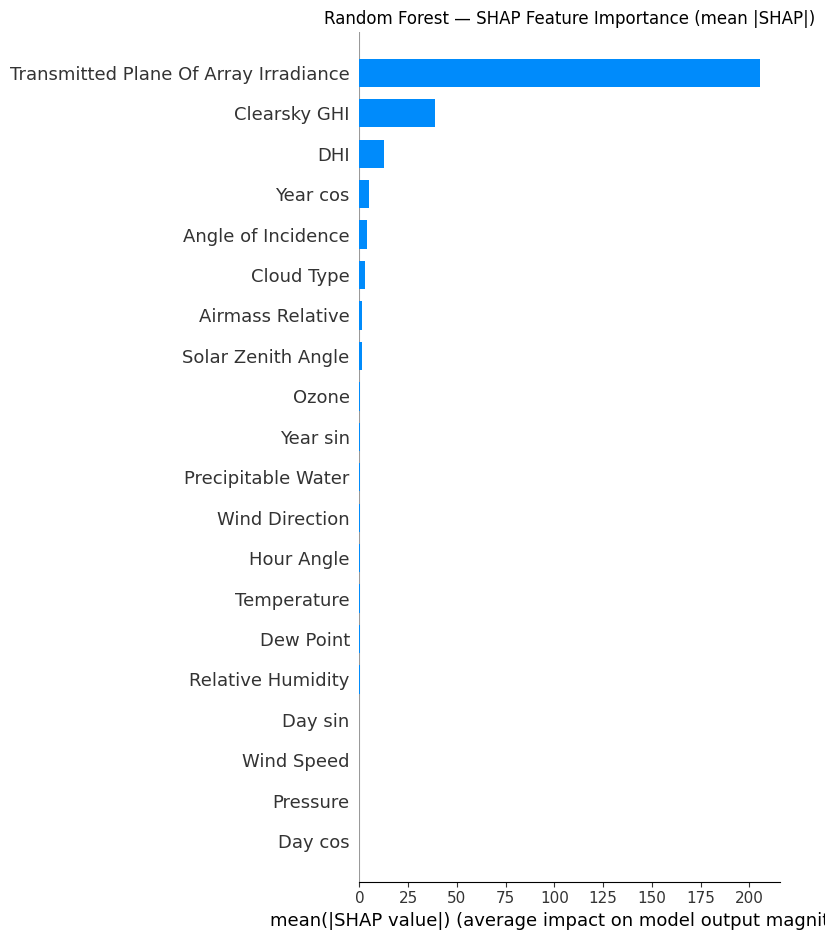

In [29]:
shap.summary_plot(rf_shap_values, X_shap, plot_type='bar', show=False)
plt.title('Random Forest — SHAP Feature Importance (mean |SHAP|)')
plt.tight_layout(); plt.show()


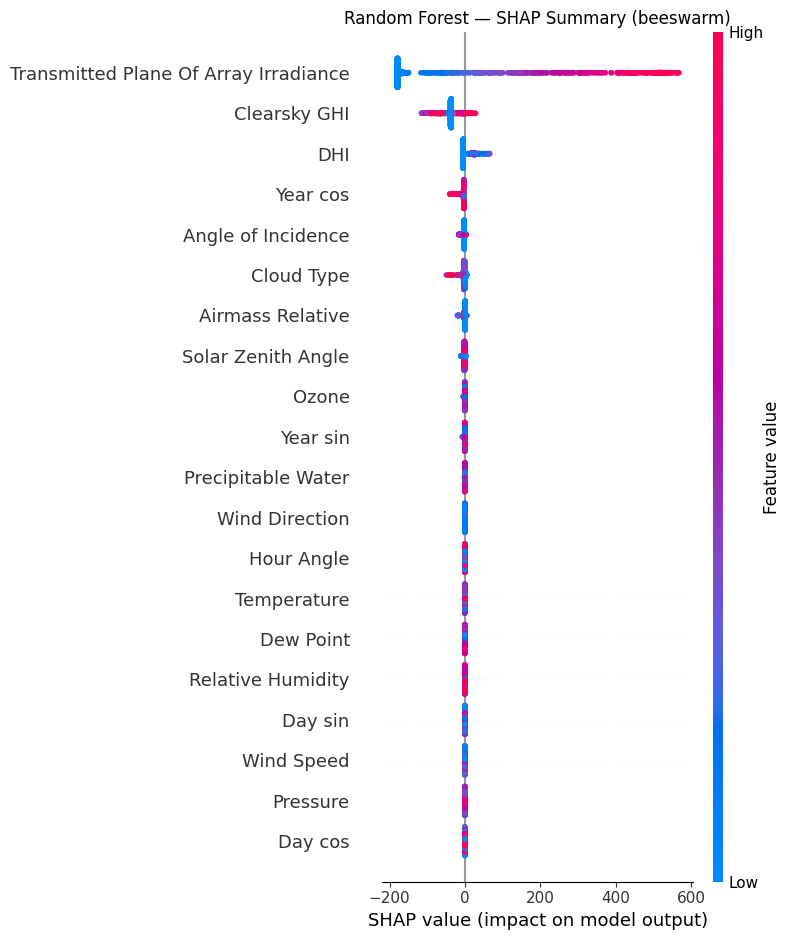

In [30]:
shap.summary_plot(rf_shap_values, X_shap, show=False)
plt.title('Random Forest — SHAP Summary (beeswarm)')
plt.tight_layout(); plt.show()


### SHAP — XGBoost


In [31]:
xgb_explainer   = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_shap)
print("SHAP values shape:", np.shape(xgb_shap_values))


SHAP values shape: (1000, 22)


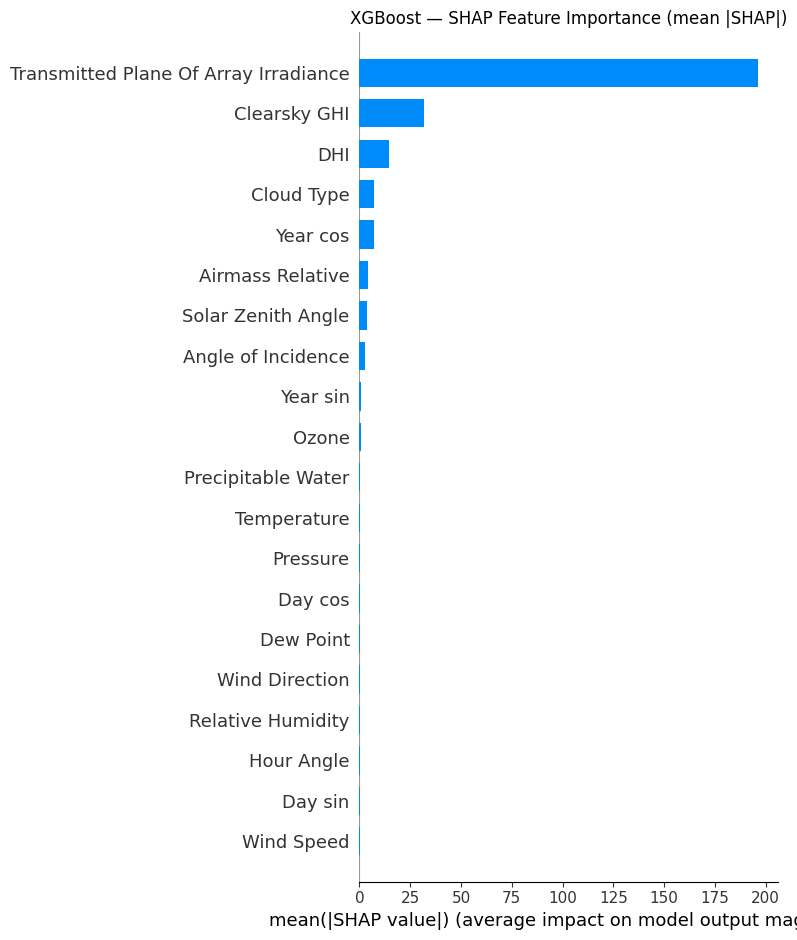

In [32]:
shap.summary_plot(xgb_shap_values, X_shap, plot_type='bar', show=False)
plt.title('XGBoost — SHAP Feature Importance (mean |SHAP|)')
plt.tight_layout(); plt.show()


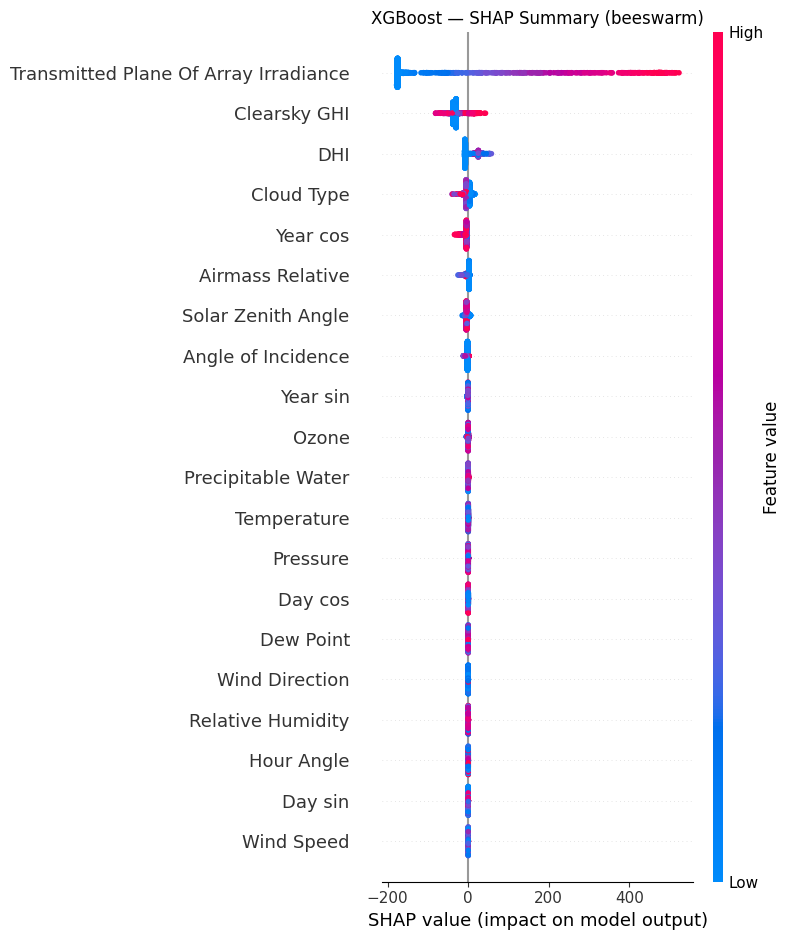

In [33]:
shap.summary_plot(xgb_shap_values, X_shap, show=False)
plt.title('XGBoost — SHAP Summary (beeswarm)')
plt.tight_layout(); plt.show()


## Combined Feature Ranking

Average rank across RF-MDI, XGB-gain, RF-SHAP, XGB-SHAP.
Lower `avg_rank` = more consistently important.


In [34]:
importance_table = pd.DataFrame({
    'RF_MDI'         : rf_model.feature_importances_,
    'XGB_gain'       : xgb_model.feature_importances_,
    'RF_mean_|SHAP|' : np.abs(rf_shap_values).mean(axis=0),
    'XGB_mean_|SHAP|': np.abs(xgb_shap_values).mean(axis=0),
}, index=X.columns)

ranks = importance_table.rank(ascending=False)
importance_table['avg_rank'] = ranks.mean(axis=1)
importance_table = importance_table.sort_values('avg_rank')

print("=== Combined Feature Ranking (lower avg_rank = more important) ===")
print(importance_table.to_string(float_format='{:.4f}'.format))


=== Combined Feature Ranking (lower avg_rank = more important) ===
                                       RF_MDI  XGB_gain  RF_mean_|SHAP|  XGB_mean_|SHAP|  avg_rank
Transmitted Plane Of Array Irradiance  0.9710    0.8649        205.3720         196.2732    1.0000
Clearsky GHI                           0.0200    0.0931         38.8524          31.7164    2.0000
DHI                                    0.0043    0.0119         12.6681          14.4572    3.0000
Cloud Type                             0.0007    0.0091          2.6764           6.9971    5.2500
Year cos                               0.0010    0.0041          4.7154           6.9387    5.2500
Airmass Relative                       0.0009    0.0076          1.3634           3.9977    6.0000
Angle of Incidence                     0.0013    0.0022          3.8076           2.8184    6.2500
Solar Zenith Angle                     0.0005    0.0058          1.2524           3.7896    7.2500
Year sin                               0.0

## Final Feature Selection & Dataset Export

We take the **top-ranked features** that are:
1. Physically meaningful (professor-approved)
2. Consistently ranked across all four importance metrics
3. Not simulated/derived from the target

This becomes the input dataset for the GHI time-series forecasting model.


In [35]:
# ── Select top features for the final forecasting dataset ────────────────────
# Take top-N by avg_rank, excluding any that are unavailable in df_2020
TOP_N = 10
top_features = importance_table.head(TOP_N).index.tolist()

# Ensure all selected features exist
top_features = [f for f in top_features if f in df_2020.columns]

print(f"Top {TOP_N} features selected for forecasting dataset:")
for i, f in enumerate(top_features, 1):
    rank = importance_table.loc[f, 'avg_rank']
    print(f"  {i:2d}. {f:<45} avg_rank={rank:.1f}")


Top 10 features selected for forecasting dataset:
   1. Transmitted Plane Of Array Irradiance         avg_rank=1.0
   2. Clearsky GHI                                  avg_rank=2.0
   3. DHI                                           avg_rank=3.0
   4. Cloud Type                                    avg_rank=5.2
   5. Year cos                                      avg_rank=5.2
   6. Airmass Relative                              avg_rank=6.0
   7. Angle of Incidence                            avg_rank=6.2
   8. Solar Zenith Angle                            avg_rank=7.2
   9. Year sin                                      avg_rank=9.5
  10. Ozone                                         avg_rank=9.5


In [36]:
# ── Build and export the final forecasting CSV ───────────────────────────────
forecast_df = df_2020[top_features + [TARGET]].copy()
forecast_df = forecast_df.dropna()

# Format date column for forecasting frameworks (TimeXer-compatible)
forecast_df.insert(0, 'date',
    [f"{ts.year}/{ts.month}/{ts.day} {ts.hour}:{ts.minute:02d}"
     for ts in forecast_df.index])

# Rename target to 'OT' (standard for TimeXer / Time-Series Library)
forecast_df = forecast_df.rename(columns={TARGET: 'OT'})

output_path = "./ghi_kaohsiung_dsc2_2020.csv"
forecast_df.to_csv(output_path, index=False)

print(f"✅ Saved: {output_path}")
print(f"   Shape : {forecast_df.shape}")
print(f"   Period: {df_2020.index.min().date()} → {df_2020.index.max().date()}")
print(f"   Columns: {list(forecast_df.columns)}")


✅ Saved: ./ghi_kaohsiung_dsc2_2020.csv
   Shape : (52704, 12)
   Period: 2020-01-01 → 2020-12-31
   Columns: ['date', 'Transmitted Plane Of Array Irradiance', 'Clearsky GHI', 'DHI', 'Cloud Type', 'Year cos', 'Airmass Relative', 'Angle of Incidence', 'Solar Zenith Angle', 'Year sin', 'Ozone', 'OT']


In [37]:
forecast_df.head(10)

,date,Transmitted Plane Of Array Irradiance,Clearsky GHI,DHI,Cloud Type,Year cos,Airmass Relative,Angle of Incidence,Solar Zenith Angle,Year sin,Ozone,OT
Date Time,,,,,,,,,,,,
2020-01-01 00:00:00+08:00,2020/1/1 0:00,0.0,0.0,0.0,4.0,0.999969,0.0,0.0,179.47,-0.007885,0.238,0.0
2020-01-01 00:10:00+08:00,2020/1/1 0:10,0.0,0.0,0.0,4.0,0.999970,0.0,0.0,178.11,-0.007765,0.238,0.0
2020-01-01 00:20:00+08:00,2020/1/1 0:20,0.0,0.0,0.0,4.0,0.999971,0.0,0.0,175.82,-0.007646,0.238,0.0
2020-01-01 00:30:00+08:00,2020/1/1 0:30,0.0,0.0,0.0,4.0,0.999972,0.0,0.0,173.52,-0.007526,0.238,0.0
2020-01-01 00:40:00+08:00,2020/1/1 0:40,0.0,0.0,0.0,4.0,0.999973,0.0,0.0,171.22,-0.007407,0.238,0.0
2020-01-01 00:50:00+08:00,2020/1/1 0:50,0.0,0.0,0.0,4.0,0.999973,0.0,0.0,168.92,-0.007287,0.238,0.0
2020-01-01 01:00:00+08:00,2020/1/1 1:00,0.0,0.0,0.0,4.0,0.999974,0.0,0.0,166.62,-0.007168,0.238,0.0
2020-01-01 01:10:00+08:00,2020/1/1 1:10,0.0,0.0,0.0,4.0,0.999975,0.0,0.0,164.32,-0.007048,0.238,0.0
2020-01-01 01:20:00+08:00,2020/1/1 1:20,0.0,0.0,0.0,4.0,0.999976,0.0,0.0,162.02,-0.006929,0.238,0.0


In [38]:
# ── Quick sanity check: correlation of selected features with GHI ────────────
final_corr = (
    forecast_df.drop(columns=['date'])
    .rename(columns={'OT': 'GHI'})
    .corr()['GHI']
    .drop('GHI')
    .sort_values(key=abs, ascending=False)
)
print("Pearson r with GHI (final feature set):")
print(final_corr.to_string())


Pearson r with GHI (final feature set):
Transmitted Plane Of Array Irradiance    0.987564
Clearsky GHI                             0.924866
Solar Zenith Angle                      -0.820173
DHI                                      0.785864
Angle of Incidence                       0.264286
Cloud Type                              -0.131761
Ozone                                    0.115347
Year cos                                -0.110636
Year sin                                 0.053415
Airmass Relative                        -0.028793
